Title: ERA5_SMARD_Comparison_curtailment.ipynb

Purpose: Compare the ERA5 Model output with the SMARD Data and the curtailment data from 

Author: Onno Nennecke on 15.10.2025 Modified: 19.10.2025

Input data: 

- ERA5 Residual Load Timeseries
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_timeseries_week.nc
- SMARD Production and demand Timeseries
    - This file lies here: /home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv
- Curtailment data
    - This file lies here: '/home/onennecke/Capacity_data/redispatch.csv'

Output data:

- Curtailment Plot: 
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt


In [2]:
ERA5_dataset = xr.open_dataset('/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_hist_timeseries.nc')

ERA5_dataset.load()

<xarray.Dataset> Size: 321kB
Dimensions:        (time: 3650)
Coordinates:
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            <U9 36B 'ERA5_week'
    run            <U4 16B 'hist'
    ESM_run        <U14 56B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         <U4 16B 'week'
Data variables:
    temp           (time) float64 29kB 1.323 3.335 2.591 ... 0.7396 0.4142
    demand         (time) float64 29kB 1.504e+03 1.479e+03 ... 1.515e+03
    sfcWind        (time) float32 15kB 7.507 11.86 9.267 ... 6.159 8.049 8.775
    rsds           (time) float32 15kB 30.54 19.51 17.85 ... 28.84 26.3 31.92
    tas            (time) float32 15kB 1.771 3.587 3.046 ... 0.2238 1.512 1.194
    tasmax         (time) float32 15kB 3.431 5.871 4.704 ... 2.446 2.709 3.361
    wind_off_prod  (time) float64 29kB 221.1 221.2 221.2 ... 179.2 221.1 221.1
    wind_on_prod   (time) float64 29kB 491.1 1.168e+03 739.7 ... 592.8 602.7
    solar_prod     (time) float64 29kB 80.6 41.14 40.3 85.6 ... 78.49 72.3 91.06
    total_prod     (time) float64 29kB 792.8 1.431e+03 1.001e+03 ... 886.3 914.8
    Netto          (time) float64 29kB -710.8 -47.95 -486.7 ... -624.5 -600.0
    Residual_load  (time) float64 29kB 710.8 47.95 486.7 ... 624.5 600.0

### Load SMARD data

In [ ]:
SMARD_data_prod = pd.read_csv('/home/onennecke/SMARD_data/Realisierte_Erzeugung_201501010000_202505010000_Tag.csv', sep=';', decimal=',', thousands='.')

In [4]:

date = pd.to_datetime(SMARD_data_prod['Datum von'].astype(str).str.zfill(8), format='%d%m%Y')
wind_off_prod = SMARD_data_prod['Wind Offshore [MWh] Berechnete Auflösungen']
wind_on_prod = SMARD_data_prod['Wind Onshore [MWh] Berechnete Auflösungen']
solar_prod = SMARD_data_prod['Photovoltaik [MWh] Berechnete Auflösungen']

df = pd.DataFrame({
    'date': date,
    # 'demand_SMARD': demand_sm / 1000,  # Convert to GWh
    'wind_offshore_SMARD': wind_off_prod / 1000,  # Convert to GWh
    'wind_onshore_SMARD': wind_on_prod / 1000,  # Convert to GWh
    'solar_SMARD': solar_prod / 1000,  # Convert to GWh
    # 'total_production_SMARD': total_prod / 1000,  # Convert to GWh
    # 'residual_load_SMARD': residual_load / 1000,  # Convert to GWh
})


In [5]:
# Cut data to the same time period as ERA5 data (2015-2024)
df = df[(df['date'] >= '2015-01-01') & (df['date'] <= '2024-12-31')]
# Remove leap days
df = df[~((df['date'].dt.month == 2) & (df['date'].dt.day == 29))]
df

,date,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD
0,2015-01-01,12.50850,298.79175,17.08025
1,2015-01-02,10.32925,591.62075,7.75900
2,2015-01-03,12.11950,457.04350,7.23475
3,2015-01-04,11.53850,379.02950,19.98250
4,2015-01-05,7.74550,219.62350,26.52225
...,...,...,...,...
3648,2024-12-27,2.94125,46.42200,61.20575
3649,2024-12-28,22.34775,31.44225,61.08850
3650,2024-12-29,97.29825,257.39450,39.71900
3651,2024-12-30,61.18675,534.34725,22.92750


### Combine both datasets

In [6]:
# df['sfcWind'] = ERA5_dataset['sfcWind'].values
# df['rsds'] = ERA5_dataset['rsds'].values
# df['tas'] = ERA5_dataset['tas'].values
# df['tasmax'] = ERA5_dataset['tasmax'].values
# df['temp_ERA5'] = ERA5_dataset['temp'].values
# df['demand_ERA5_wwd'] = ERA5_dataset_wwd['demand'].values
# df['demand_ERA5'] = ERA5_dataset['demand'].values
# df['RL_ERA5'] = ERA5_dataset['Residual_load']

df['wind_offshore_ERA5'] = ERA5_dataset['wind_off_prod'].values
df['wind_onshore_ERA5'] = ERA5_dataset['wind_on_prod'].values
df['solar_ERA5'] = ERA5_dataset['solar_prod'].values
# df['total_production_ERA5'] = df['wind_offshore_ERA5'] + df['wind_onshore_ERA5'] + df['solar_ERA5']
# df['total_production_ERA5_check'] = ERA5_dataset['total_prod'].values

### Cut to July 2022

In [7]:
# Cut data to the same time period as ERA5 data (2015-2024)
df = df[(df['date'] >= '2022-07-01') & (df['date'] <= '2024-12-31')]
df

,date,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,wind_offshore_ERA5,wind_onshore_ERA5,solar_ERA5
2738,2022-07-01,67.74525,215.02500,134.64200,53.923039,53.022008,315.424419
2739,2022-07-02,61.20075,105.32950,334.46050,27.865426,6.711580,620.018684
2740,2022-07-03,25.37825,151.22500,320.00050,28.189630,10.322997,579.626582
2741,2022-07-04,73.40450,142.66575,284.81325,83.483835,67.116891,539.677999
2742,2022-07-05,75.26700,144.84400,286.03375,74.307947,64.241019,504.983380
...,...,...,...,...,...,...,...
3648,2024-12-27,2.94125,46.42200,61.20575,3.365156,3.016724,89.412102
3649,2024-12-28,22.34775,31.44225,61.08850,16.483505,7.948019,96.813345
3650,2024-12-29,97.29825,257.39450,39.71900,179.232693,216.614284,78.486280
3651,2024-12-30,61.18675,534.34725,22.92750,221.142798,592.833808,72.300325


In [8]:
# Calculate monthly values (sum, mean) for all columns of df
df_monthly_sum = df.resample('M', on='date').sum().reset_index()
df_monthly_sum
# Change date field to YYYY-MM without any day shown
df_monthly_sum['date'] = df_monthly_sum['date'].dt.to_period('M').dt.to_timestamp()
# Remove the day from the date field
df_monthly_sum['date'] = df_monthly_sum['date'].dt.strftime('%Y-%m')
df_monthly_sum

/tmp/ipykernel_1208728/2197453884.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly_sum = df.resample('M', on='date').sum().reset_index()


,date,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,wind_offshore_ERA5,wind_onshore_ERA5,solar_ERA5
0,2022-07,1773.07925,5489.58825,7846.61525,1757.469916,2308.967620,15004.181357
1,2022-08,1018.19275,3512.43500,7228.86700,778.004212,1039.313244,13108.506079
2,2022-09,1910.45225,6171.74875,4726.08225,2126.055116,3687.025169,8481.988037
3,2022-10,2466.03625,8595.91525,3512.12650,2610.541048,4701.659991,5802.150597
4,2022-11,2818.89575,10082.87025,1671.93200,3757.843430,6877.387028,3122.025457
5,2022-12,2676.69775,9372.94850,640.60150,3156.302298,7779.591061,1947.424403
6,2023-01,2730.53800,14643.04525,824.25150,3928.991718,12437.025542,2283.865954
7,2023-02,1639.37100,10406.60750,2309.49025,2435.674624,7716.725504,4443.556750
8,2023-03,2434.29850,12079.63575,3735.17775,3012.657808,7667.494787,7539.471694
9,2023-04,1734.89075,8346.80625,5522.11825,2278.308584,4196.039927,10622.404463


### Load curtailment data

In [9]:
# Read CSV data
path = '/home/onennecke/Capacity_data/redispatch.csv'
df_curtailed = pd.read_csv(path, sep=';', decimal=',', thousands='.')
# Remove everything after 2024-12
df_curtailed = df_curtailed[~df_curtailed['Jahr/Monat'].str.contains('2025')]

# df_curtailed

In [10]:
# add both dataframes together (just stick them together column by column)
df_combined = pd.concat([df_monthly_sum, df_curtailed], axis=1)
df_combined

# Calculate % of curtailment from curtailed compared to total production from SMARD
df_combined['curtailment_offs_%'] = (df_combined['Wind Offshore'] / df_combined['wind_offshore_SMARD']) * 100
df_combined['curtailment_ons_%'] = (df_combined['Wind Onshore'] / df_combined['wind_onshore_SMARD']) * 100
df_combined['curtailment_solar_%'] = (df_combined['Photovoltaik'] / df_combined['solar_SMARD']) * 100
df_combined

,date,wind_offshore_SMARD,wind_onshore_SMARD,solar_SMARD,wind_offshore_ERA5,wind_onshore_ERA5,solar_ERA5,Jahr/Monat,Wind Offshore,Wind Onshore,Photovoltaik,curtailment_offs_%,curtailment_ons_%,curtailment_solar_%
0,2022-07,1773.07925,5489.58825,7846.61525,1757.469916,2308.967620,15004.181357,Jul 2022,124.16,236.13,99.56,7.002507,4.301416,1.268827
1,2022-08,1018.19275,3512.43500,7228.86700,778.004212,1039.313244,13108.506079,Aug 2022,4.33,29.02,75.29,0.425263,0.826207,1.041519
2,2022-09,1910.45225,6171.74875,4726.08225,2126.055116,3687.025169,8481.988037,Sep 2022,198.72,171.79,52.01,10.401726,2.783490,1.100489
3,2022-10,2466.03625,8595.91525,3512.12650,2610.541048,4701.659991,5802.150597,Okt 2022,335.94,206.61,41.11,13.622671,2.403583,1.170516
4,2022-11,2818.89575,10082.87025,1671.93200,3757.843430,6877.387028,3122.025457,Nov 2022,567.76,260.83,11.10,20.141220,2.586863,0.663903
5,2022-12,2676.69775,9372.94850,640.60150,3156.302298,7779.591061,1947.424403,Dez 2022,372.07,196.02,4.95,13.900337,2.091338,0.772711
6,2023-01,2730.53800,14643.04525,824.25150,3928.991718,12437.025542,2283.865954,Jan 2023,746.09,643.18,10.64,27.323919,4.392392,1.290868
7,2023-02,1639.37100,10406.60750,2309.49025,2435.674624,7716.725504,4443.556750,Feb 2023,719.07,526.76,30.07,43.862555,5.061784,1.302019
8,2023-03,2434.29850,12079.63575,3735.17775,3012.657808,7667.494787,7539.471694,Mrz 2023,698.86,416.34,53.80,28.708887,3.446627,1.440360
9,2023-04,1734.89075,8346.80625,5522.11825,2278.308584,4196.039927,10622.404463,Apr 2023,508.64,198.84,66.19,29.318273,2.382229,1.198634


In [11]:
# Calculate mean, max, min and total curtailment per technology
curtailment_stats = df_combined[['Wind Offshore', 'Wind Onshore', 'Photovoltaik', 'curtailment_offs_%', 'curtailment_ons_%', 'curtailment_solar_%']].agg(['mean', 'max', 'min', 'sum'])
curtailment_stats

,Wind Offshore,Wind Onshore,Photovoltaik,curtailment_offs_%,curtailment_ons_%,curtailment_solar_%
mean,396.433667,282.479667,79.492,19.223398,2.938431,1.367452
max,775.960000,643.180000,264.390,43.862555,5.061784,3.258556
min,4.330000,29.020000,4.950,0.425263,0.826207,0.440613
sum,11893.010000,8474.390000,2384.760,576.701928,88.152923,41.023575


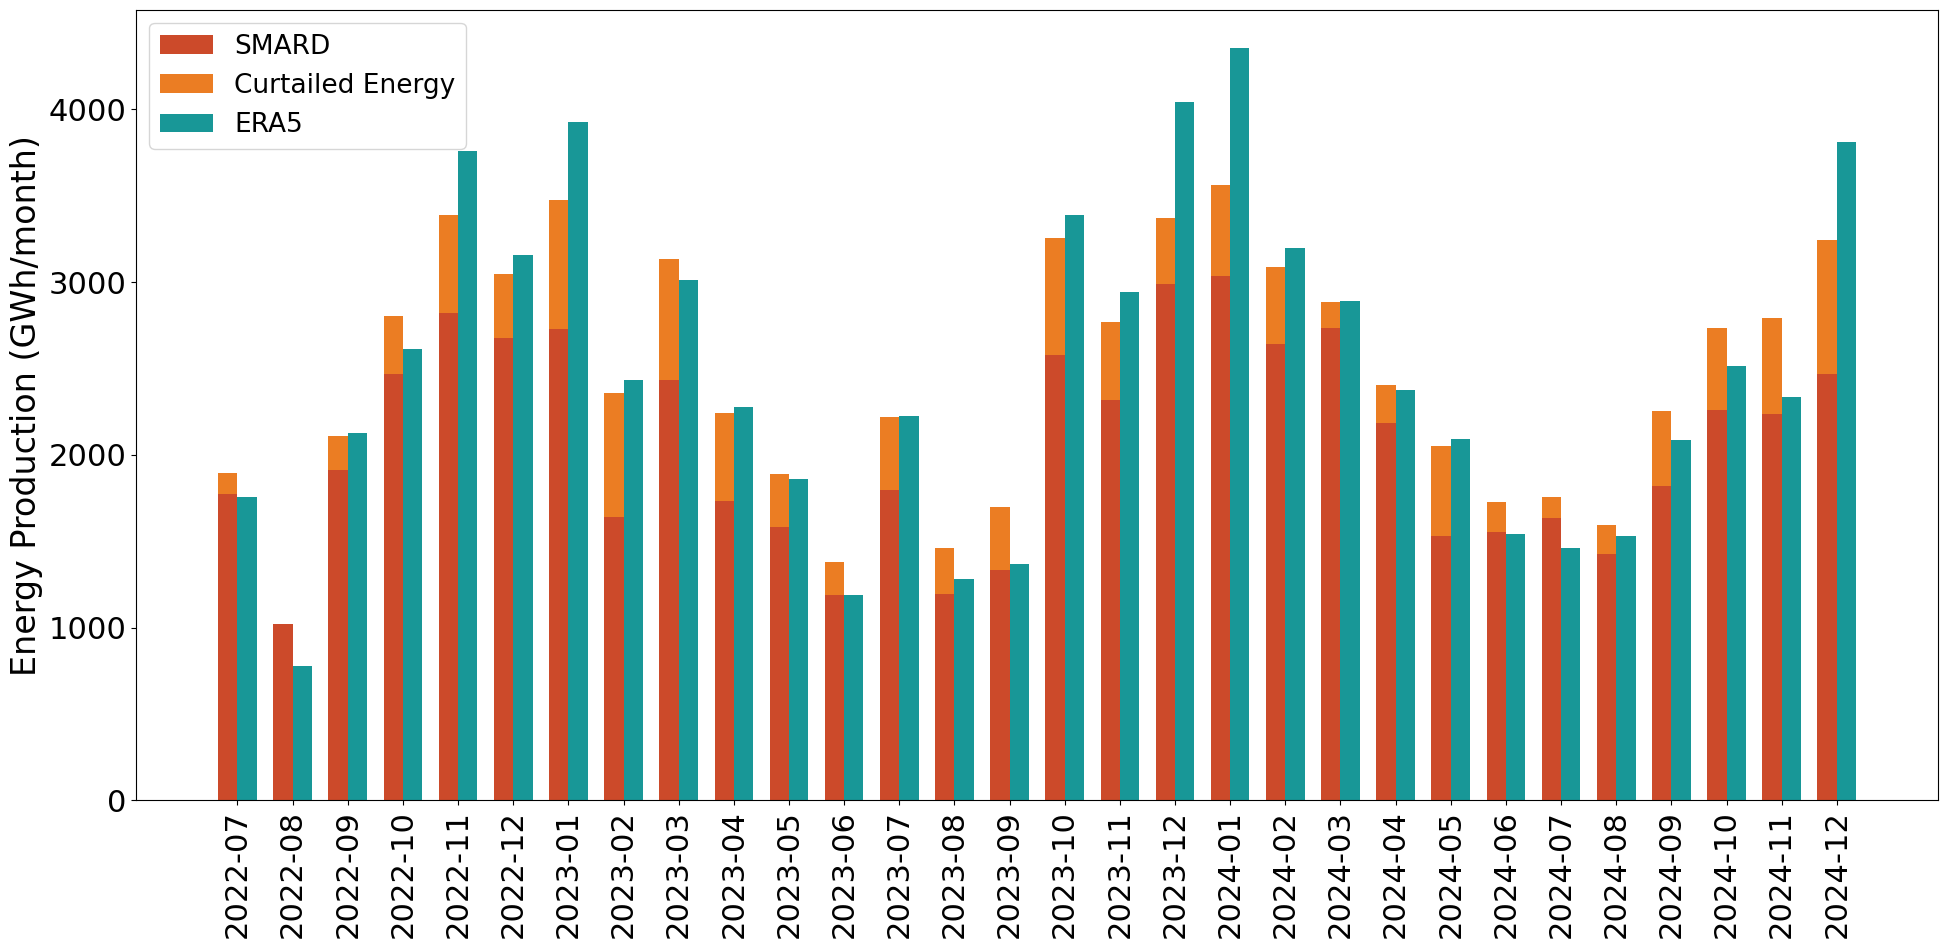

In [14]:
mpl.rcParams.update({
    'font.size': 18+6,
    'axes.titlesize': 20+6,
    'axes.labelsize': 18+6,
    'xtick.labelsize': 16+6,
    'ytick.labelsize': 16+6,
    'legend.fontsize': 13+6,
    'figure.titlesize': 20+6,
})

# change to 'offshore', 'onshore' or 'solar'
variable = 'offshore'

var_map = {
    'offshore': {
        'smard': 'wind_offshore_SMARD',
        'era5': 'wind_offshore_ERA5',
        'curtailed': 'Wind Offshore'
    },
    'onshore': {
        'smard': 'wind_onshore_SMARD',
        'era5': 'wind_onshore_ERA5',
        'curtailed': 'Wind Onshore'
    },
    'solar': {
        'smard': 'solar_SMARD',
        'era5': 'solar_ERA5',
        'curtailed': 'Photovoltaik'
    }
}

m = var_map[variable]
smard = df_combined[m['smard']].astype(float).reset_index(drop=True)
curtailed = df_combined[m['curtailed']].astype(float).reset_index(drop=True)
era5 = df_combined[m['era5']].astype(float).reset_index(drop=True)
months = df_combined['date'].astype(str).reset_index(drop=True)

n = len(months)
idx = np.arange(n)
width = 0.35

plt.figure(figsize=(20, 10))
# stacked bar: SMARD bottom, curtailed on top (left position)
plt.bar(idx - width/2, smard, width, color="#CC4A2A")
plt.bar(idx - width/2, curtailed, width, bottom=smard, color="#EB7D23")

# ERA5 bar (right position)
plt.bar(idx + width/2, era5, width, color="#189797")

plt.ylabel('Energy Production (GWh/month)')
plt.xticks(idx, months, rotation=90)
# plt.xticks(idx, months, rotation=45, ha='right')

plt.legend(['SMARD', 'Curtailed Energy', 'ERA5'], loc='upper left')

plt.tight_layout()
# Save figure
plt.savefig(f'/home/onennecke/Code/Figures/curtailment_{variable}.png', dpi=300)

plt.show()